# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'

# Load Data

In [3]:
## Dipole FF
Lambda2 = 0.71
GEn0 = 1
GMn0 = -1.91304272
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load $G_E^n$ Sum-Rules baseline Fitting Results w/ radius constraints

In [4]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2e_n = np.zeros(N, dtype=float)
Ze_n = np.zeros(N, dtype=float)
GE_fit_n = np.zeros(N, dtype=float)
GE_pos_n = np.zeros(N, dtype=float)
GE_neg_n = np.zeros(N, dtype=float)
GErat_fit_n = np.zeros(N, dtype=float)
GErat_pos_n = np.zeros(N, dtype=float)
GErat_neg_n = np.zeros(N, dtype=float)
GED_n = np.zeros(N, dtype=float)
dGEnGD = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2e_n[i]=float(values[0])
    Ze_n[i]=float(values[1])
    GE_fit_n[i]=float(values[2])
    GE_pos_n[i]=float(values[2])+abs(float(values[3]))
    GE_neg_n[i]=float(values[2])-abs(float(values[3]))
    Gdip = float(values[4])
#    Gdip = 1./(1.+float(values[0])/0.71)**2
    GED_n[i]=Gdip*GEn0
    GErat_fit_n[i]=GE_fit_n[i]/GED_n[i]
    GErat_pos_n[i]=GE_pos_n[i]/GED_n[i]
    GErat_neg_n[i]=GE_neg_n[i]/GED_n[i] 
#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GEn.dat


## Load $G_E^n$ Sum-Rules  Fitting Results w/o radius constraints

In [5]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn_noRad.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2e_n1 = np.zeros(N, dtype=float)
Ze_n1 = np.zeros(N, dtype=float)
GE_fit_n1 = np.zeros(N, dtype=float)
GE_pos_n1 = np.zeros(N, dtype=float)
GE_neg_n1 = np.zeros(N, dtype=float)
GErat_fit_n1 = np.zeros(N, dtype=float)
GErat_pos_n1 = np.zeros(N, dtype=float)
GErat_neg_n1 = np.zeros(N, dtype=float)
GED_n1 = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2e_n1[i]=float(values[0])
    Ze_n1[i]=float(values[1])
    GE_fit_n1[i]=float(values[2])
    GE_pos_n1[i]=float(values[2])+abs(float(values[3]))
    GE_neg_n1[i]=float(values[2])-abs(float(values[3]))
    Gdip = float(values[4])
    #Gdip = 1./(1.+float(values[0])/0.71)**2
    GED_n1[i]=Gdip*GEn0   
    GErat_fit_n1[i]=GE_fit_n1[i]/GED_n1[i]
    GErat_pos_n1[i]=GE_pos_n1[i]/GED_n1[i]
    GErat_neg_n1[i]=GE_neg_n1[i]/GED_n1[i] 

#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GEn_noRad.dat


## Load $G_M^n$ Sum-Rules baseline Fitting Results w/ radius constraints

In [6]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2m_n = np.zeros(N, dtype=float)
Zm_n = np.zeros(N, dtype=float)
GM_fit_n = np.zeros(N, dtype=float)
GM_pos_n = np.zeros(N, dtype=float)
GM_neg_n = np.zeros(N, dtype=float)
GMrat_fit_n = np.zeros(N, dtype=float)
GMrat_pos_n = np.zeros(N, dtype=float)
GMrat_neg_n = np.zeros(N, dtype=float)
GMD_n = np.zeros(N, dtype=float)
dGMnGD = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2m_n[i]=float(values[0])
    Zm_n[i]=float(values[1])
    GM_fit_n[i]=float(values[2])
    GM_pos_n[i]=float(values[2])+abs(float(values[3]))
    GM_neg_n[i]=float(values[2])-abs(float(values[3]))
    #Gdip = 1./(1.+float(values[0])/0.71)**2
    Gdip = float(values[4])
    GMD_n[i]=Gdip*GMn0       
    GMrat_fit_n[i]=GM_fit_n[i]/GMD_n[i]
    GMrat_pos_n[i]=GM_pos_n[i]/GMD_n[i]
    GMrat_neg_n[i]=GM_neg_n[i]/GMD_n[i] 
#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GMn.dat


## Load $G_M^n$ Sum-Rules  Fitting Results w/o radius constraints

In [7]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn_noRad.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2m_n1 = np.zeros(N, dtype=float)
Zm_n1 = np.zeros(N, dtype=float)
GM_fit_n1 = np.zeros(N, dtype=float)
GM_pos_n1 = np.zeros(N, dtype=float)
GM_neg_n1 = np.zeros(N, dtype=float)
GMrat_fit_n1 = np.zeros(N, dtype=float)
GMrat_pos_n1 = np.zeros(N, dtype=float)
GMrat_neg_n1 = np.zeros(N, dtype=float)
GMD_n1 = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2m_n1[i]=float(values[0])
    Zm_n1[i]=float(values[1])
    GM_fit_n1[i]=float(values[2])
    GM_pos_n1[i]=float(values[2])+abs(float(values[3]))
    GM_neg_n1[i]=float(values[2])-abs(float(values[3]))
#    Gdip = 1./(1.+float(values[0])/0.71)**2
    Gdip = float(values[4])
    GMD_n1[i]=Gdip*GMn0
    GMrat_fit_n1[i]=GM_fit_n1[i]/GMD_n1[i]
    GMrat_pos_n1[i]=GM_pos_n1[i]/GMD_n1[i]
    GMrat_neg_n1[i]=GM_neg_n1[i]/GMD_n1[i] 

#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GMn_noRad.dat


# Richard's Parameterization

$$ log_{10}\frac{\delta G}{G_D} = (L+c_0)\Theta_a(L_1-L) 
                                +\sum_{i=1}^{N}(c_i+d_i L)[\Theta_a(L_i-L)-\Theta_a(L_{i+1}-L)]
                                +log_{10}(E_{\inf})\Theta_a(L-L_{N+1})$$
where $L=log_{10}(Q^2)$, $\Theta_{a}(x)=[1+10^{-ax}]^{-1}$. $a=1$.

In [8]:
## Define Functions
def THETA(x):
    th = 1./(1.+10**(-x))
    return th

## Richard's parameterized formula
def dG_RH(kQ2, Einf,c0,c, d, Lp):
    n = len(c)
    np = len(d)
    npp = len(Lp)
    if n!=np or n!=npp-1:
        print '*** ERROR, the length of "c"(%d) or "d"(%d) or "L"(%d) are not equal!!!'%(n, np, npp)
        
    L = log10(kQ2)  
    term1 = (L+c0)*THETA(Lp[0]-L)
    term3 = log10(Einf)*THETA(L-Lp[npp-1])
    term2 = 0.0
    for i in range(0,n):
        term2 += (c[i]+d[i]*L) * ( THETA(Lp[i]-L) - THETA(Lp[i+1]-L) )
    
    ##LOG10(dG/GD)
    dG_GD = (term1+term2+term3) 
    ##Note: return dG/GD here
    return (10.**dG_GD) 

## Parameters

In [9]:
## Parameters
Einf_GEp=3.157685
Einf_GMp =1.790780
Einf_GEn=6.363856
Einf_GMn =  4.292528

##########################
## 7 Terms parameters

## GEp:
c0_GEp = -0.98747988
#d_rEp=0.013678 
c_GEp= np.array([0.97460930,-11.38337563,-30.43370261,62.68229745,73.67221720,34.86137611,5.64262801]) 	
d_GEp= np.array([-0.58247051,-5.12848743, -37.64872610,-71.62778591,-33.47257995,-7.85872169, -1.07425315]) 
L_GEp= np.array([-2.0, -1.0, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0])


## GMp:
c0_GMp=-0.69234179
#d_rMp=0.009981 
c_GMp= np.array([ 0.46036606, -3.34378878,  -42.94335515, 96.73864903, 29.00837832, -79.55863425, -3.84552302])
d_GMp= np.array([-0.87517968, -1.76558252, -26.57292205,-78.45383846,33.47872790,27.42543881,-0.12503961]) 
L_GMp= np.array([-2.0, -1.0, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0])


## GEn:
c0_GEn= -2.02012561
#d_rEn2=0.00223 
c_GEn= np.array([ -1.73637421, -25.55959961, 26.77011270, 37.60967814, -62.66066571, -16.61559329, -3.14585188])
d_GEn= np.array([ -1.56794580, -11.57929560, -31.31159809, 46.86646839, 38.89453446, 5.18947055,  0.24166171]) 
L_GEn= np.array([ -2.0, -1.0,-0.5, 0.0, 0.5, 1.0, 2.0, 3.0])


## ## GMn:
## c0_GMn= 0.08365061
## #d_rMn = 0.085686 
## c_GMn= np.array([ -0.12272856, 16.62435535,  36.38242969,  -55.15525480, 18.65169750, 16.85664775, 4.22318526])
## d_GMn= np.array([ -1.46900674, -1.25845363, 34.74102094, 29.48484271, -34.53586919, -7.26951261, -1.18937864]) 
## L_GMn= np.array([ -2.0, -1.0,-0.5, 0.0, 0.5, 1.0, 2.0, 3.0])

# ## GMn: -- 07/03/2017
c0_GMn= -0.32955945
#d_rMn = 0.085686 
c_GMn= np.array([ 0.29048108, 17.03756388,  36.79565444,  -54.74205070, 19.06489612 , 17.26985422, 4.63639406])
d_GMn= np.array([ -1.46900684 , -1.25845693 , 34.74102622 , 29.48485920 , -34.53586430, -7.26951119 , -1.18937836]) 
L_GMn= np.array([ -2.0, -1.0,-0.5, 0.0, 0.5, 1.0, 2.0, 3.0])

##########################
## 5 Terms parameters
## GEp:
c0_GEp5=-0.99959125
# d_rEp=0.013302 
c_GEp5 = np.array([2.42147739, 0.71594965, 4.15930349, -1.11520973,-0.55258018]) 
d_GEp5 = np.array([ -0.57651805, -0.40696275, -1.56967082, 1.06823140, -0.12987175]) 
L_GEp5 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

## GMp:
c0_GMp5 = -0.69156036
# d_rMp=0.009999 
c_GMp5 = np.array([0.24782941,2.58825267,1.15520734,5.93012850,3.88750162]) 
d_GMp5 = np.array([-1.14687459, -1.33804811,0.65599095, -3.31118121, -1.11984805]) 

## GEn:
c0_GEn5=-2.02517380
# d_rEn2=0.00220 
c_GEn5 = np.array([ -0.71438167, 2.17422854, 2.48587860, 2.57114710, 0.56019404])
d_GEn5 = np.array([-1.82555135, -0.78957241, -2.86130295, -1.29962824, -0.37809484]) 
L_GEn5 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

## GMn: -- 07/03/2017
c0_GMn5=-0.32663855
# d_rMn=0.086264 
c_GMn5= np.array([   0.23233237, 5.41338123, 2.51706481, -12.25509149, -5.99225341]) 
d_GMn5= np.array([ -1.16628065, 0.64199162, 6.32905161, 6.22054376 , 1.19648224]) 
L_GMn5= np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])


## GetFF

In [11]:
ND = 12

In [12]:
############################/
############################/
## Parameterized Form Factor Central Value and Error
############################/
## ID = 1 for GEp, 2 for GMp, 3 for GEn, 4 for GMn, 
## Q2 in GeV^2
##
# The parameterization formula returns the uncertainty devided by G(0)*GD, where 
#  GD(Q2) = 1./(1+Q2/0.71)^2
# and GEp(0) =1, GMp(0) = 2.79284356, GEn(0) = 1, GMn(0) = -1.91304272,
#
# The parameterization formula for the Form Factor value is:
#  $$ GN(z) = sum_{i=0}^{N=13}(a_i * z^i) 
#Note that the return value has been divided by (G(Q2=0)*G_Dip)
#
# The parameterization formula for the Form Factor error is:
# $$ log_{10}\frac{\delta G}{G_D} = (L+c_0)\Theta_a(L_1-L) 
#                                 +\sum_{i=1}^{N}(c_i+d_i L)[\Theta_a(L_i-L)-\Theta_a(L_{i+1}-L)]
#                                 +log_{10}(E_{\inf})\Theta_a(L-L_{N+1})$$
# where $L=log_{10}(Q^2)$, $\Theta_{a}(x)=[1+10^{-ax}]^{-1}$. $a=1$.

import numpy as np
from math import *
def GetFF2(kID, kQ2):# {{{
    #################################################
    #### z-Expansion Parameters for Form Factor Values
    #################################################{{{
    N=13;#### a0+a[kmax] ,for proton, kmax=12, for neutron, kmax=10 but I set the last two to be zeros
  
    GEp_Coef_Fit_Full = np.array([0.23923548887477869, -1.1070730540280407, 1.452300215920139, 0.44315594198423214, -2.3720765725887762, 1.3324108648344339, 1.5316259621574055, -4.2560097248729436, 3.8183591898840232, 1.3901703668945125, -5.2650904746882219, 3.6218345581983442, -0.82884276256967127]
)
    GMp_Coef_Fit_Full = np.array([0.73767348293370061, -3.0609333058062402, 3.4050083185972855, 1.8790302867016251, -3.9739007014506633, -3.9442915679818511, 4.373337012248343, 11.998124723666713, -15.687044230226991, -7.7848795021184429, 24.789361323144476, -16.448477520995425, 3.7169916812868848]
)
    GEn_Coef_Fit_Full = np.array([0.048919981378687416, -0.064525053911520136, -0.2408258973820159, 0.39210874487270547, 0.30044525860234683, -0.6618886871786257, -0.17563976968716144, 0.62469172446142984, -0.077684299366794995, -0.23600397525898575, 0.090401973469939723,0,0]
 )
    GMn_Coef_Fit_Full = np.array([-0.49310269090862408, 2.0652073662331643, -2.2615681356224031, -1.3602022337626483, 2.5789364221088618, 3.1803264398321676, -5.0205021294138721, -3.3501864008469395, 9.4165718620066272, -6.1177054013254235, 1.3622249016990544,0,0]
)
    #GEp_Coef_Fit = np.array([0.239235, -1.107073, 1.452300, 0.443156, -2.372077, 1.3324110, 1.531626, -4.256010, 3.81835900, 1.390170, -5.265090, 3.62183500, -0.828843]) 
    #GMp_Coef_Fit = np.array([0.737673, -3.060933, 3.405008, 1.879030, -3.973901, -3.944292, 4.373337, 11.998125, -15.687044, -7.78488, 24.789361, -16.448478, 3.7169920]) 
    #GEn_Coef_Fit = np.array([0.048920, -0.064525, -0.240826, 0.392109, 0.300445, -0.661889, -0.17564, 0.624692, -0.077684, -0.236004, 0.090402, 0.0, 0.0])
    #GMn_Coef_Fit = np.array([-0.493103,  2.065207, -2.261568, -1.360202, 2.578936, 3.180326, -5.020502, -3.350186, 9.416572, -6.117705, 1.362225, 0.0, 0.0]) #}}}

    GEp_Coef_Fit = np.around(GEp_Coef_Fit_Full, decimals=ND)
    GMp_Coef_Fit = np.around(GMp_Coef_Fit_Full, decimals=ND)
    GEn_Coef_Fit = np.around(GEn_Coef_Fit_Full, decimals=ND)
    GMn_Coef_Fit = np.around(GMn_Coef_Fit_Full, decimals=ND)
   
    #################################################
    #### Parameters for Form Factor Errors
    #################################################{{{
    Lp= np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
    ## GEp:
    Einf_GEp = 3.157685
    c0_GEp = -0.99959125
    c_GEp = np.array([2.42147739, 0.71594965, 4.15930349, -1.11520973,-0.55258018]) 
    d_GEp = np.array([ -0.57651805, -0.40696275, -1.56967082, 1.06823140, -0.12987175]) 
    ## GMp:
    Einf_GMp = 1.790780
    c0_GMp = -0.69156036
    c_GMp = np.array([0.24782941,2.58825267,1.15520734,5.93012850,3.88750162]) 
    d_GMp = np.array([-1.14687459, -1.33804811,0.65599095, -3.31118121, -1.11984805]) 
    ## GEn:
    Einf_GEn = 6.363856
    c0_GEn =-2.02517380
    c_GEn = np.array([ -0.71438167, 2.17422854, 2.48587860, 2.57114710, 0.56019404])
    d_GEn = np.array([-1.82555135, -0.78957241, -2.86130295, -1.29962824, -0.37809484]) 
    ## GMn:
    Einf_GMn =  4.292528
    c0_GMn = -0.32663855
    c_GMn = np.array([   0.23233237, 5.41338123, 2.51706481, -12.25509149, -5.99225341]) 
    d_GMn = np.array([ -1.16628065, 0.64199162, 6.32905161, 6.22054376 , 1.19648224]) #}}}

    ## Define #{{{
    GEp0 = 1.0
    GMp0 = 2.79284356
    GEn0 = 1.0
    GMn0 = -1.91304272
    tcut = 0.0779191396 
    t0 = -0.7 

    GNQ20 = 0.0
    Einf = 0.0
    c0 = 0.0
    c = np.zeros(5, dtype=float)
    d = np.zeros(5, dtype=float)
    GN_Coef_Fit = np.zeros(N, dtype=float) #}}}
 
    if kID==1:# {{{
        GNQ20 = GEp0
        c0 = c0_GEp
        Einf = Einf_GEp
        c = c_GEp
        d = d_GEp
        GN_Coef_Fit = GEp_Coef_Fit
    elif kID==2:
        GNQ20 = GMp0
        c0 = c0_GMp
        Einf = Einf_GMp
        c = c_GMp
        d = d_GMp
        GN_Coef_Fit = GMp_Coef_Fit
    elif kID==3:
        GNQ20 = GEn0
        c0 = c0_GEn
        Einf = Einf_GEn
        c = c_GEn
        d = d_GEn
        GN_Coef_Fit = GEn_Coef_Fit
    elif kID==4:
        GNQ20 = GMn0
        c0 = c0_GMn
        Einf = Einf_GMn
        c = c_GMn
        d = d_GMn
        GN_Coef_Fit = GMn_Coef_Fit
    else:
        print '*** ERROR, ID is not one of these: 1->GEp, 2->GMp, 3->GEn, 4->GMn'
        GNGD_Fit = -1.0
        GNGD_Err = -2.0
        return GNGD_Fit, GNGD_Err# }}}

    ## Apply the z-expansion formula
    z = (sqrt(tcut+kQ2)-sqrt(tcut-t0))/(sqrt(tcut+kQ2)+sqrt(tcut-t0)) 
    GNQ2 = 0.0
    for i in range(0,N):
        GNQ2 += GN_Coef_Fit[i] * (z**i)
    GDip= 1./(1. + kQ2/0.71)**2
    GNGD_Fit = GNQ2 / (GNQ20 * GDip)
 
    ## Apply the Parameterization formula for error
    L = log10(kQ2) 
    X0= Lp[0]-L
    THETA0= 1./(1.+10**(-X0))
    TERM1 = (L+c0)*THETA0
    TERM2 = 0.0
    for i in range(0,5):
        X1= Lp[i]-L
        THETA1= 1./(1.+10**(-X1))
        X2= Lp[i+1]-L
        THETA2= 1./(1.+10**(-X2))
        TERM2 += (c[i]+d[i]*L) * ( THETA1 - THETA2 )

    X3= L-Lp[5]
    THETA3= 1./(1.+10**(-X3))
    TERM3 = log10(Einf)*THETA3

    ##LOG10(dG/G(0)/GD)
    GNGD_Err = 10.**(TERM1+TERM2+TERM3)

    return GNGD_Fit, GNGD_Err
# }}}


# Calculating Errors 

In [20]:
## Model Dependent Errors by using different data sets

GE_err_fit = np.zeros(len(Q2e_n), dtype=float)
GM_err_fit = np.zeros(len(Q2e_n), dtype=float)
GE_err_sum = np.zeros(len(Q2e_n), dtype=float)
GM_err_sum = np.zeros(len(Q2e_n), dtype=float)
GE_err_rh = np.zeros(len(Q2e_n), dtype=float)
GM_err_rh = np.zeros(len(Q2e_n), dtype=float)
GE_fit_rh = np.zeros(len(Q2e_n), dtype=float)
GM_fit_rh = np.zeros(len(Q2e_n), dtype=float)
of = open('neutron_baseline_seg7.dat','w')
print >> of, '##%10s %14s %14s %14s %14s %14s %14s'%('Q2','GEn/GD','dGEn/GD','dGEn_Par/GD','GMn/muGD','dGMn/muGD','dGMn_Par/muGD')

from GetFF import *
for i in range(0, len(Q2e_n)):    
        GE_err_fit[i] = abs(GErat_pos_n[i] - GErat_fit_n[i])# use the central fit values w/ radius constraint
        GE_err_sum[i] = abs(GErat_pos_n[i] - GErat_fit_n[i])# use the error also w/ radius contraints

        GM_err_fit[i] = abs(GMrat_pos_n[i]  - GMrat_fit_n[i]) # use the central fit values w/ radius constraint
        GM_err_sum[i] = abs(GMrat_pos_n1[i] - GMrat_fit_n1[i]) # use the error w/o radius contraints
      
        GE_fit_rh[i], GE_err_rh[i] = GetFF2(3, Q2e_n[i])
        GM_fit_rh[i], GM_err_rh[i] = GetFF2(4, Q2e_n[i])

        #GE_err_rh[i] = dG_RH(Q2e_n[i], Einf_GEn, c0_GEn5, c_GEn5, d_GEn5, L_GEn5 ) #/abs(GEn0)
        #GM_err_rh[i] = dG_RH(Q2e_n[i], Einf_GMn, c0_GMn5, c_GMn5, d_GMn5, L_GMn5 ) #/abs(GMp0)      
        GE_err_rh[i] = dG_RH(Q2e_n[i], Einf_GEn, c0_GEn, c_GEn, d_GEn, L_GEn ) #/abs(GEn0)
        GM_err_rh[i] = dG_RH(Q2e_n[i], Einf_GMn, c0_GMn, c_GMn, d_GMn, L_GMn ) #/abs(GMn0)
        
        #print >> of, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2e_n[i], GErat_fit_n[i], GE_err_sum[i], GE_err_rh[i],GMrat_fit_n[i], GM_err_sum[i], GM_err_rh[i]  )
        print >> of, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2e_n[i], GE_fit_rh[i], GE_err_sum[i], GE_err_rh[i],GM_fit_rh[i], GM_err_sum[i], GM_err_rh[i]  )
of.close()
        

# Plot Errors

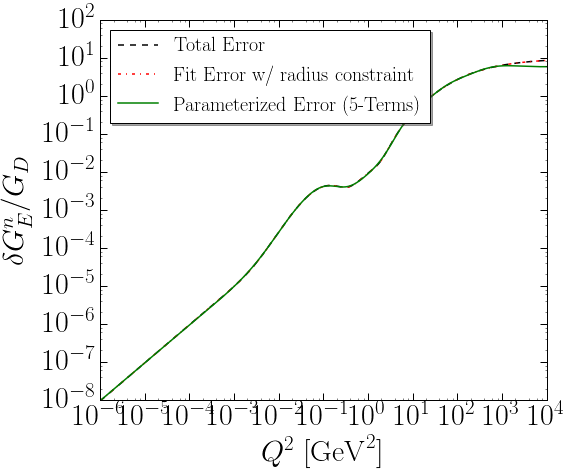

In [21]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2e_n, GE_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2e_n, GE_err_fit, 'k-.', color='r',  label='Fit Error w/ radius constraint', linewidth=1.5)
axes.plot(Q2e_n, GE_err_rh, 'k-', color='g',  label='Parameterized Error (5-Terms)', linewidth=1.5)

axes.set_xlim(1e-6, 1e4)
axes.set_ylim(1e-8, 100)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_E^n/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#plt.savefig('GEn_Error_Curves_round6.pdf',bbox_inches='tight')
plt.savefig('GEn_Error_Curves_precise.pdf',bbox_inches='tight')

# plt.savefig('GEn_Error_Curves_seg5.eps',bbox_inches='tight')
# plt.savefig('GEn_Error_Curves_seg5.png',bbox_inches='tight')

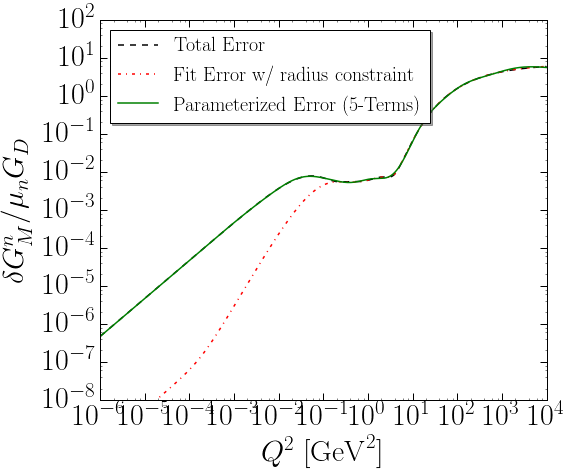

In [22]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2e_n, GM_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2e_n, GM_err_fit, 'k-.', color='r',  label='Fit Error w/ radius constraint', linewidth=1.5)
axes.plot(Q2e_n, GM_err_rh, 'k-', color='g',  label='Parameterized Error (5-Terms)', linewidth=1.5)

axes.set_xlim(1e-6, 1e4)
axes.set_ylim(1e-8, 100)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_M^n/\mu_n G_{D}$', fontsize=30)
#axes.set_ylabel('$\delta G_M^n/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#plt.savefig('GMn_Error_Curves_round6.pdf',bbox_inches='tight')
plt.savefig('GMn_Error_Curves_precise.pdf',bbox_inches='tight')

# plt.savefig('GMn_Error_Curves_seg5.eps',bbox_inches='tight')
# plt.savefig('GMn_Error_Curves_seg5.png',bbox_inches='tight')

# Ploting Central Curves

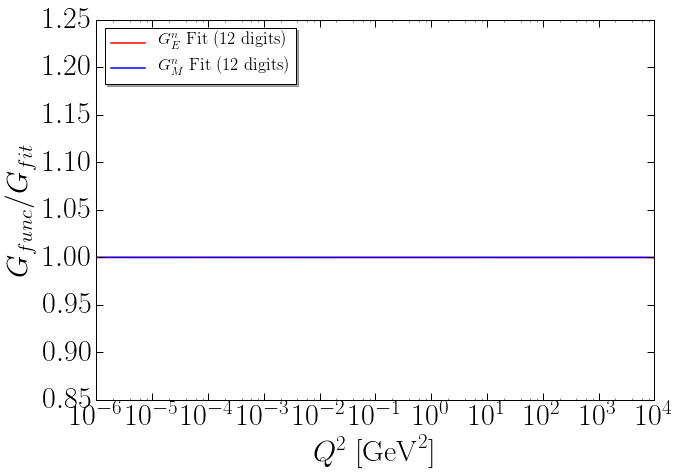

In [16]:
## 

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2e_n, GE_fit_rh/(GErat_fit_n), 'k-', color='r',  label='$G_E^n$ Fit (%d digits)'%ND, linewidth=1.5)

axes.plot(Q2e_n, GM_fit_rh/(GMrat_fit_n), 'k-', color='b',  label='$G_M^n$ Fit (%d digits)'%ND, linewidth=1.5)

#axes.set_xlim(2000, 2200)
axes.set_ylim(0.85, 1.25)
axes.set_xscale('log')
#axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$G_{func}/G_{fit}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc=' right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('neutron_central_curve_%d_digits.pdf'%ND,bbox_inches='tight')
